# SLM-Based Framework for Imputation and Prediction (Regression)
### Model: **TabM** | Dataset: `city_day.csv` | Target: `AQI`

**Pipeline:**
| Step | Description | Output Folder |
|------|-------------|---------------|
| 0 | Install dependencies | — |
| 1 | Imports & configuration | — |
| 2 | Setup project folders | `data/raw/`, `data/processed/`, `models/`, `results/`, `logs/` |
| 3 | Load raw dataset | `data/raw/` |
| 4 | EDA — exploratory data analysis | `results/` |
| 5 | Feature engineering & preprocessing | — |
| 6 | Traditional imputation (Median) | `data/processed/` |
| 7 | **TabM architecture** | — |
| 8 | Training & evaluation utilities | `logs/` |
| 9 | Train TabM — Traditional (Median) imputation | `models/`, `logs/` |
| 10 | SLM-based imputation (RandomForest) | `data/processed/` |
| 11 | Train TabM — SLM-based imputation | `models/`, `logs/` |
| 12 | Training curve plots | `results/` |
| 13 | Predicted vs Actual plots | `results/` |
| 14 | AQI distribution plots | `results/` |
| 15 | Final results & comparison | `results/` |
| 16 | Folder summary | — |


## Step 0: Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn --quiet
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu --quiet
!{sys.executable} -m pip install ipykernel --quiet
print("All packages ready! Restart kernel if first time.")



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All packages ready! Restart kernel if first time.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Imports & Configuration

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Setup complete.')


Device : cpu
Setup complete.


## Step 2: Setup Project Folders

In [3]:
# ── Auto-detect project root ─────────────────────────────────────────────────
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) \
    if os.path.basename(NOTEBOOK_DIR) == 'notebooks' else NOTEBOOK_DIR

# ── Create all folders ────────────────────────────────────────────────────────
for folder in ['data/raw', 'data/processed', 'models', 'results', 'logs']:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

DATA_RAW       = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR     = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')
LOGS_DIR       = os.path.join(PROJECT_ROOT, 'logs')

print(f'Project Root   : {PROJECT_ROOT}')
print(f'data/raw/      : {DATA_RAW}')
print(f'data/processed/: {DATA_PROCESSED}')
print(f'models/        : {MODELS_DIR}')
print(f'results/       : {RESULTS_DIR}')
print(f'logs/          : {LOGS_DIR}')


Project Root   : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project
data/raw/      : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\raw
data/processed/: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed
models/        : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models
results/       : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results
logs/          : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs


## Step 3: Load Raw Dataset (`city_day.csv`)
Place `city_day.csv` inside `data/raw/` before running this cell.

**Dataset:** India Air Quality Index — 29 531 daily readings from 26 cities (2015–2020).  
**Columns:** `City`, `Date`, `PM2.5`, `PM10`, `NO`, `NO2`, `NOx`, `NH3`, `CO`, `SO2`, `O3`, `Benzene`, `Toluene`, `Xylene`, `AQI`, `AQI_Bucket`.  
**Target:** `AQI` (continuous regression).


In [4]:
csv_path = os.path.join(DATA_RAW, 'city_day.csv')

# ── Copy dataset to data/raw/ if running from repo root ──────────────────────
# Uncomment and adjust if your CSV is elsewhere:
# shutil.copy('city_day.csv', csv_path)

df_raw = pd.read_csv(csv_path)

print(f'Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Date range : {df_raw["Date"].min()}  →  {df_raw["Date"].max()}')
print(f'Cities ({df_raw["City"].nunique()}) : {sorted(df_raw["City"].unique())}')
print(f'\nColumn dtypes:')
print(df_raw.dtypes)
print('\nFirst 3 rows:')
display(df_raw.head(3))


Shape  : 29,531 rows × 16 columns
Date range : 2015-01-01  →  2020-07-01
Cities (26) : ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

Column dtypes:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

First 3 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN


## Step 4: EDA — Exploratory Data Analysis

In [5]:
print('── Dataset Info ──')
print(df_raw.info())

print('\n── Missing Values ──')
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df     = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing'] > 0].sort_values('Missing %', ascending=False)
print(miss_df)

print('\n── AQI Stats ──')
print(df_raw['AQI'].describe().round(2))

print('\n── AQI_Bucket distribution ──')
print(df_raw['AQI_Bucket'].value_counts())


── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None

── Missing Values ──
            Missing  Missing %
Xylene        18109    

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_eda.png


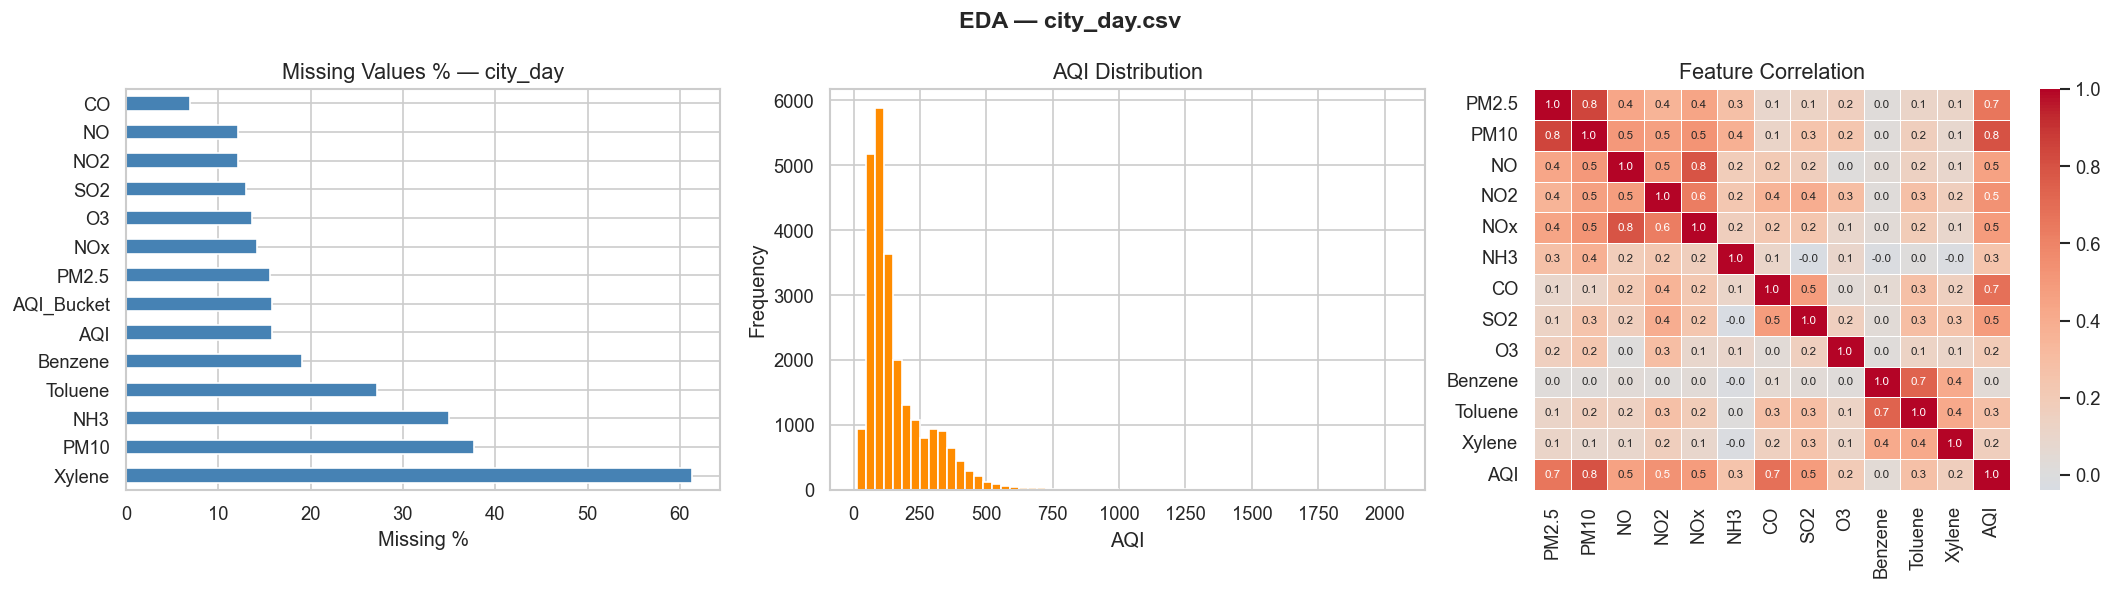

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Missing value bar chart
miss_df['Missing %'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Values % — city_day', fontsize=13)
axes[0].set_xlabel('Missing %')

# AQI distribution
df_raw['AQI'].dropna().plot(kind='hist', bins=60, ax=axes[1],
                             color='darkorange', edgecolor='white')
axes[1].set_title('AQI Distribution', fontsize=13)
axes[1].set_xlabel('AQI')

# Correlation heatmap
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
corr = df_raw[num_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', center=0, annot=True,
            fmt='.1f', linewidths=0.3, annot_kws={'size': 7})
axes[2].set_title('Feature Correlation', fontsize=13)

plt.suptitle('EDA — city_day.csv', fontsize=14, fontweight='bold')
plt.tight_layout()
eda_path = os.path.join(RESULTS_DIR, 'cityday_eda.png')
plt.savefig(eda_path, bbox_inches='tight')
print(f'Saved: {eda_path}')
plt.show()


Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_aqi_by_city.png


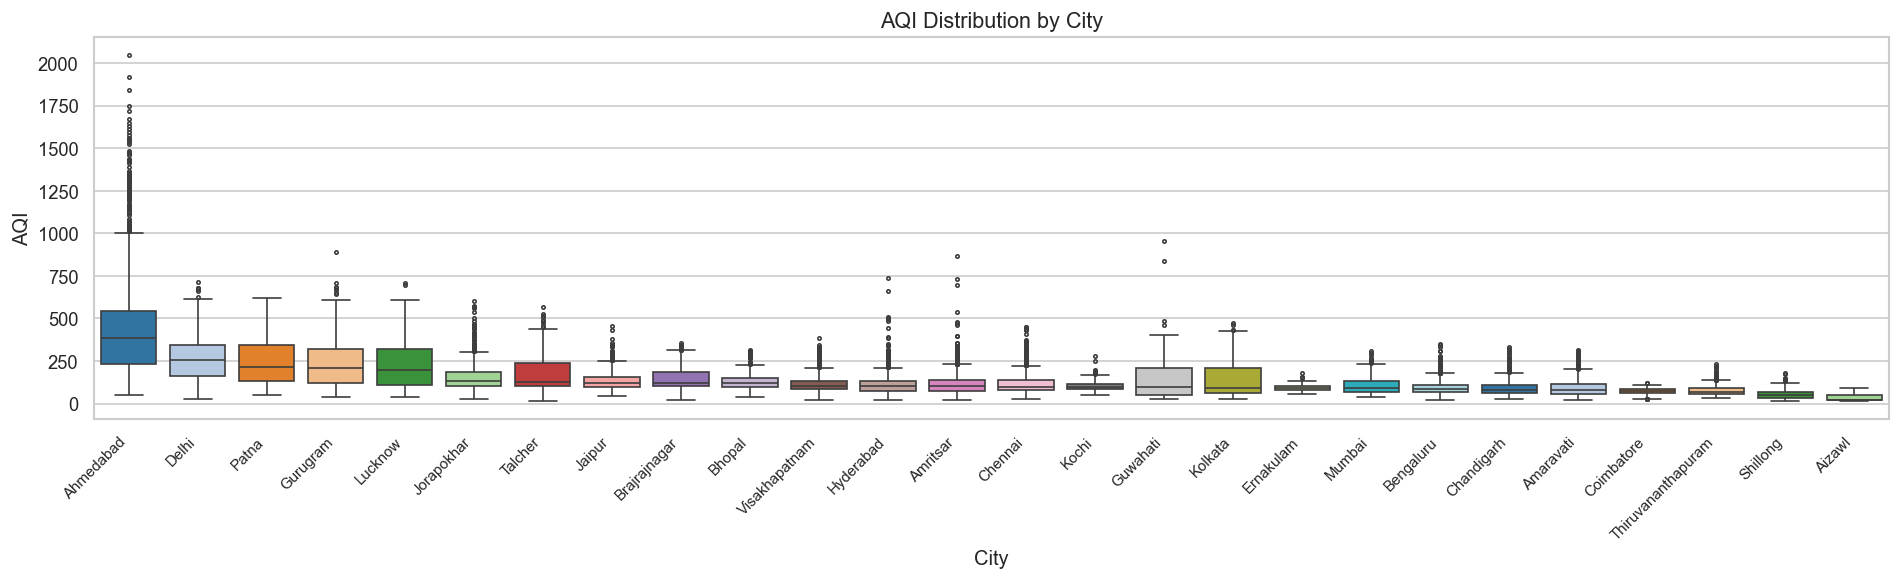

In [7]:
# ── AQI by city box-plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
order = df_raw.groupby('City')['AQI'].median().sort_values(ascending=False).index
sns.boxplot(data=df_raw, x='City', y='AQI', order=order,
            palette='tab20', ax=ax, fliersize=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_title('AQI Distribution by City', fontsize=13)
plt.tight_layout()
city_path = os.path.join(RESULTS_DIR, 'cityday_aqi_by_city.png')
plt.savefig(city_path, bbox_inches='tight')
print(f'Saved: {city_path}')
plt.show()


## Step 5: Preprocessing — Feature Engineering

**Actions:**
- Parse `Date` → `Year`, `Month`, `Day`, `DayOfWeek`, `WeekOfYear`
- One-hot encode `City` (26 cities → 25 dummy columns)
- Drop `AQI_Bucket` (string label derived from AQI — data leakage if kept)
- Drop rows where target `AQI` is missing


In [8]:
df = df_raw.copy()

# ── 5.1  Parse Date into numeric temporal features ────────────────────────────
df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Mon … 6=Sun
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df.drop(columns=['Date'], inplace=True)
print('Date expanded into: Year, Month, Day, DayOfWeek, WeekOfYear')

# ── 5.2  One-hot encode City ──────────────────────────────────────────────────
df = pd.get_dummies(df, columns=['City'], drop_first=True)
print(f'City one-hot columns added. Total columns: {df.shape[1]}')

# ── 5.3  Drop AQI_Bucket (data leakage — directly derived from AQI) ──────────
df.drop(columns=['AQI_Bucket'], errors='ignore', inplace=True)
print('Dropped AQI_Bucket (data leakage column)')

# ── 5.4  Define TARGET and FEATURE columns ───────────────────────────────────
TARGET       = 'AQI'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# ── 5.5  Drop rows with missing AQI (target must be known for supervised learning)
df_clean = df.dropna(subset=[TARGET]).reset_index(drop=True)
X_raw = df_clean[FEATURE_COLS]
y     = df_clean[TARGET].values.astype(np.float32)

print(f'\nFeature columns ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)
print(f'\nX shape : {X_raw.shape}')
print(f'y shape : {y.shape}')
print(f'y  — mean={y.mean():.2f}  std={y.std():.2f}  min={y.min():.1f}  max={y.max():.1f}')

# Save cleaned (pre-imputation) data
clean_path = os.path.join(DATA_PROCESSED, 'cityday_cleaned.csv')
df_clean.to_csv(clean_path, index=False)
print(f'\nSaved: {clean_path}')

df_full = df.copy()   # keep full df (with NaN features) for SLM imputation in Step 10


Date expanded into: Year, Month, Day, DayOfWeek, WeekOfYear
City one-hot columns added. Total columns: 44
Dropped AQI_Bucket (data leakage column)

Feature columns (42):
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Ernakulam', 'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar', 'City_Kochi', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher', 'City_Thiruvananthapuram', 'City_Visakhapatnam']

X shape : (24850, 42)
y shape : (24850,)
y  — mean=166.46  std=140.69  min=13.0  max=2049.0

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed\cityday_cleaned.csv


## Step 6: Traditional Imputation (Median) → `data/processed/`

Median imputation fills each missing feature cell with the **column median** of
the non-missing values.  Simple, fast, and robust to outliers.


In [9]:
# ── 6.1  Median imputation on feature columns ────────────────────────────────
imputer  = SimpleImputer(strategy='median')
X_imp    = imputer.fit_transform(X_raw)
print(f'Any NaN after median imputation : {np.isnan(X_imp).any()}')

# ── 6.2  Save median-imputed dataset → data/processed/ ───────────────────────
df_median_save        = pd.DataFrame(X_imp, columns=FEATURE_COLS)
df_median_save[TARGET] = y
median_path = os.path.join(DATA_PROCESSED, 'cityday_median_imputed.csv')
df_median_save.to_csv(median_path, index=False)
print(f'Saved: {median_path}')

# ── 6.3  Standard-scale features (mean=0, std=1) ─────────────────────────────
# Scaling applied AFTER imputation so medians aren't distorted
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# ── 6.4  Train / Val / Test split  70 / 15 / 15 ──────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

n_features = X_train.shape[1]
print(f'\nSplit — Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'n_features : {n_features}')


Any NaN after median imputation : False
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed\cityday_median_imputed.csv

Split — Train: 17,395  Val: 3,727  Test: 3,728
n_features : 42


## Step 7: TabM Architecture

**TabM** (Tabular Multi-head MLP) is a modern tabular deep-learning model that
creates **k independent MLP parameter copies** per sample and fuses them via
an ensemble head — giving the expressiveness of an ensemble without k× inference cost.

### How TabM works
```
Input x ∈ ℝᶠ
  └─► EmbeddingBlock: linear → BN → GELU  →  h ∈ ℝᵈ
        └─► k copies of h  (expand + small random perturbation)
              └─► k × MLP(h)  — each copy passes through its own weight slice
                    └─► mean-pool across k copies  →  scalar AQI prediction
```

**Key hyperparameters:**
| Parameter | Default | Meaning |
|-----------|---------|---------|
| `d_embedding` | 64 | Hidden dimension |
| `n_blocks` | 3 | Depth of per-copy MLP |
| `k` | 8 | Number of ensemble copies |
| `dropout` | 0.1 | Dropout inside each block |


In [10]:
# =============================================================================
# TabM — Tabular Multi-head MLP
# =============================================================================
# Reference: Gorishniy et al. (2024) "TabM: Advancing Tabular Deep Learning
#            with Parameter-Efficient Ensembling"
# =============================================================================

class TabMEmbedding(nn.Module):
    """
    Projects each raw feature scalar through a shared linear layer
    followed by BatchNorm + GELU to produce an initial embedding h ∈ R^d.
    This is the 'feature tokeniser' equivalent for TabM.
    """
    def __init__(self, n_features: int, d_embedding: int, dropout: float = 0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(n_features, d_embedding),
            nn.BatchNorm1d(d_embedding),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, F)  →  h : (B, d)
        return self.block(x)


class TabMBlock(nn.Module):
    """
    One residual MLP block applied independently to each of the k copies.
    Uses a 'weight-sharing with additive perturbation' pattern:
      the main Linear layer is shared; k small bias vectors are per-copy.
    """
    def __init__(self, d: int, k: int, dropout: float = 0.1):
        super().__init__()
        self.linear     = nn.Linear(d, d, bias=False)   # shared weight W
        # Per-copy additive bias:  shape (k, d)
        self.bias_k     = nn.Parameter(torch.zeros(k, d))
        nn.init.normal_(self.bias_k, std=0.01)

        self.bn         = nn.BatchNorm1d(d)
        self.act        = nn.GELU()
        self.dropout    = nn.Dropout(dropout)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h : (B, k, d)
        B, k, d = h.shape
        # Shared linear — reshape to (B*k, d) for nn.Linear
        out = self.linear(h.view(B * k, d)).view(B, k, d)
        # Add per-copy learned bias
        out = out + self.bias_k.unsqueeze(0)                 # (B, k, d)
        # BatchNorm over the (B*k, d) view
        out = self.bn(out.view(B * k, d)).view(B, k, d)
        out = self.act(out)
        out = self.dropout(out)
        return h + out                                        # residual


class TabM(nn.Module):
    """
    TabM — Tabular Multi-head MLP

    Args:
        n_features   : number of input features (F)
        d_embedding  : width of each hidden layer (default 64)
        n_blocks     : number of TabMBlock layers (default 3)
        k            : ensemble copies (default 8)
        dropout      : dropout rate (default 0.1)
    """
    def __init__(self,
                 n_features  : int,
                 d_embedding : int   = 64,
                 n_blocks    : int   = 3,
                 k           : int   = 8,
                 dropout     : float = 0.1):
        super().__init__()
        self.k = k

        # ── 1. Embedding block: maps (B, F) → (B, d) ─────────────────────────
        self.embedding = TabMEmbedding(n_features, d_embedding, dropout)

        # ── 2. Stack of k-copy residual MLP blocks ────────────────────────────
        self.blocks = nn.ModuleList([
            TabMBlock(d_embedding, k, dropout) for _ in range(n_blocks)
        ])

        # ── 3. Regression head: mean-pool over k copies → scalar ──────────────
        self.head = nn.Sequential(
            nn.LayerNorm(d_embedding),
            nn.Linear(d_embedding, d_embedding // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_embedding // 2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Embed raw features → (B, d) ───────────────────────────────────────
        h = self.embedding(x)                       # (B, d)

        # ── Expand to k copies → (B, k, d) ───────────────────────────────────
        h = h.unsqueeze(1).expand(-1, self.k, -1).contiguous()

        # ── Pass through residual blocks ──────────────────────────────────────
        for block in self.blocks:
            h = block(h)                            # (B, k, d)

        # ── Mean-pool across the k ensemble copies → (B, d) ──────────────────
        h = h.mean(dim=1)                           # (B, d)

        # ── Regression head → (B, 1) ──────────────────────────────────────────
        out = self.head(h)                          # (B, 1)
        return out.squeeze(1)                       # (B,)


# ── Quick sanity check ────────────────────────────────────────────────────────
_dummy = torch.randn(4, 10)
_model = TabM(n_features=10, d_embedding=32, n_blocks=2, k=4)
_out   = _model(_dummy)
assert _out.shape == (4,), f"Unexpected output shape: {_out.shape}"
print(f'TabM sanity check passed — output shape: {_out.shape}')

# Count parameters
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'TabM (demo, 10 features, d=32, k=4) — {total_params:,} parameters')
del _dummy, _model, _out


TabM sanity check passed — output shape: torch.Size([4])
TabM (demo, 10 features, d=32, k=4) — 3,457 parameters


## Step 8: Training & Evaluation Utilities → `logs/`

In [11]:
def make_loader(X, y, batch_size=256, shuffle=True):
    """Wrap numpy arrays into a PyTorch DataLoader."""
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_tabm(model, X_tr, y_tr, X_val, y_val,
               epochs=150, lr=1e-3, batch_size=256,
               patience=20, label=''):
    """
    Train a TabM model with AdamW + CosineAnnealingLR + early stopping.

    Saves a training log to logs/training_log_{label}.txt.
    Returns (best_model, history_dict).
    """
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.HuberLoss()     # Huber: robust to AQI outliers (max=2049)
    loader    = make_loader(X_tr, y_tr, batch_size)

    best_val_rmse = float('inf')
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_rmse': []}
    log_lines     = []

    for epoch in range(1, epochs + 1):
        # ── Training phase ────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        # ── Validation phase ──────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.FloatTensor(X_val).to(DEVICE)).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        history['train_loss'].append(epoch_loss / len(loader))
        history['val_rmse'].append(val_rmse)

        # ── Logging every 25 epochs ───────────────────────────────────────────
        if epoch % 25 == 0 or epoch == 1:
            log = (f'  [{label}] Epoch {epoch:3d}/{epochs} | '
                   f'Loss={epoch_loss/len(loader):.4f} | '
                   f'Val RMSE={val_rmse:.4f} | Best={best_val_rmse:.4f}')
            print(log)
            log_lines.append(log)

        # ── Early stopping: keep best weights ─────────────────────────────────
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                msg = f'  Early stop at epoch {epoch}  (best val RMSE={best_val_rmse:.4f})'
                print(msg); log_lines.append(msg)
                break

    # ── Save training log → logs/ ─────────────────────────────────────────────
    log_path = os.path.join(LOGS_DIR, f'training_log_{label}.txt')
    with open(log_path, 'w') as f:
        f.write('\n'.join(log_lines))
    print(f'  Log saved : {log_path}')

    model.load_state_dict(best_state)
    return model, history


def predict_tabm(model, X):
    """Run inference; return 1-D numpy array."""
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X).to(DEVICE)).cpu().numpy()


# ── Evaluation helper ─────────────────────────────────────────────────────────
results = []

def evaluate(name, imputation, y_true, y_pred):
    """Compute RMSE / MAE / R² and append to global results list."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    entry = {'Model': name, 'Imputation': imputation,
             'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}
    results.append(entry)
    print(f'{name:25s} | {imputation:10s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return entry

print('Training & evaluation utilities ready.')


Training & evaluation utilities ready.


## Step 9: Train TabM — Traditional (Median) Imputation → `models/`, `logs/`

In [12]:
print('Training TabM on Median-imputed data...')
print(f'  n_features={n_features}  d_embedding=64  n_blocks=3  k=8  dropout=0.1')
print('-' * 60)

# ── Instantiate TabM ──────────────────────────────────────────────────────────
tabm_trad = TabM(n_features=n_features,
                 d_embedding=64,
                 n_blocks=3,
                 k=8,
                 dropout=0.1)

total_params = sum(p.numel() for p in tabm_trad.parameters() if p.requires_grad)
print(f'  Total trainable parameters : {total_params:,}')

# ── Train ─────────────────────────────────────────────────────────────────────
tabm_trad, history_trad = train_tabm(
    tabm_trad,
    X_train, y_train,
    X_val,   y_val,
    epochs=150, lr=1e-3, patience=20,
    label='Median_cityday')

# ── Evaluate on test set ──────────────────────────────────────────────────────
preds_trad = predict_tabm(tabm_trad, X_test)
evaluate('TabM', 'Median', y_test, preds_trad)

# ── Save model weights → models/ ─────────────────────────────────────────────
model_path_trad = os.path.join(MODELS_DIR, 'cityday_tabm_median.pt')
torch.save(tabm_trad.state_dict(), model_path_trad)
print(f'Saved: {model_path_trad}')


Training TabM on Median-imputed data...
  n_features=42  d_embedding=64  n_blocks=3  k=8  dropout=0.1
------------------------------------------------------------
  Total trainable parameters : 19,329
  [Median_cityday] Epoch   1/150 | Loss=162.3845 | Val RMSE=209.2097 | Best=inf
  [Median_cityday] Epoch  25/150 | Loss=27.7015 | Val RMSE=56.2120 | Best=57.0049
  [Median_cityday] Epoch  50/150 | Loss=25.7750 | Val RMSE=48.5213 | Best=48.7764
  [Median_cityday] Epoch  75/150 | Loss=24.6678 | Val RMSE=46.2851 | Best=46.1349
  [Median_cityday] Epoch 100/150 | Loss=23.9540 | Val RMSE=45.8509 | Best=45.3195
  [Median_cityday] Epoch 125/150 | Loss=23.7440 | Val RMSE=45.3782 | Best=45.1115
  Early stop at epoch 136  (best val RMSE=45.1115)
  Log saved : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs\training_log_Median_cityday.txt
TabM                      | Median     | RMSE=45.1998  MAE=20.9794  R2=0.8927
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models\cityday_t

## Step 10: SLM-Based Imputation (RandomForest) → `data/processed/`

For each feature column with missing values:
1. Use all **other** columns as input features (temporarily median-fill their NaNs).
2. Train a `RandomForestRegressor` on rows where the target column **is present**.
3. Predict the missing values and fill them in.
4. Repeat column by column in ascending order of missingness %.


In [13]:
def slm_impute(df_in, target_col=TARGET, seed=SEED):
    """
    SLM-based (RandomForest) iterative imputation.
    Processes feature columns sorted by missing % (least-missing first)
    so each subsequent imputation benefits from more complete data.
    """
    df_imp    = df_in.copy()
    feat_cols = [c for c in df_imp.columns if c != target_col]

    # Sort columns by ascending missing % so cleaner columns are imputed first
    missing_pct = {c: df_imp[c].isnull().mean() for c in feat_cols}
    cols_sorted = sorted(feat_cols, key=lambda c: missing_pct[c])

    for col in cols_sorted:
        missing_mask = df_imp[col].isnull()
        n_miss = missing_mask.sum()
        if n_miss == 0:
            continue    # nothing to impute in this column

        other_cols = [c for c in feat_cols if c != col]
        train_rows = df_imp[~missing_mask]
        pred_rows  = df_imp[missing_mask]

        # Temporarily median-fill NaNs in other_cols for RF training
        sub_imp  = SimpleImputer(strategy='median')
        X_tr_sub = sub_imp.fit_transform(train_rows[other_cols])
        X_pr_sub = sub_imp.transform(pred_rows[other_cols])
        y_tr_sub = train_rows[col].values

        # RandomForest as the SLM imputer
        rf = RandomForestRegressor(
            n_estimators=50, random_state=seed, n_jobs=-1)
        rf.fit(X_tr_sub, y_tr_sub)

        df_imp.loc[missing_mask, col] = rf.predict(X_pr_sub)
        print(f'  Imputed {n_miss:6,} values in [{col:<20}]  '
              f'(missing %={missing_pct[col]*100:.1f}%)')

    return df_imp


print('Running SLM-based imputation on city_day features...')
print('-' * 60)

# df_full contains rows where AQI may also be NaN; we impute feature NaNs only
df_slm = slm_impute(df_full)

print(f'\nAny NaN remaining in features : '
      f'{df_slm[FEATURE_COLS].isnull().values.any()}')

# ── Save SLM-imputed dataset → data/processed/ ───────────────────────────────
slm_path = os.path.join(DATA_PROCESSED, 'cityday_slm_imputed.csv')
df_slm.to_csv(slm_path, index=False)
print(f'Saved: {slm_path}')


Running SLM-based imputation on city_day features...
------------------------------------------------------------
  Imputed  2,059 values in [CO                  ]  (missing %=7.0%)
  Imputed  3,582 values in [NO                  ]  (missing %=12.1%)
  Imputed  3,585 values in [NO2                 ]  (missing %=12.1%)
  Imputed  3,854 values in [SO2                 ]  (missing %=13.1%)
  Imputed  4,022 values in [O3                  ]  (missing %=13.6%)
  Imputed  4,185 values in [NOx                 ]  (missing %=14.2%)
  Imputed  4,598 values in [PM2.5               ]  (missing %=15.6%)
  Imputed  5,623 values in [Benzene             ]  (missing %=19.0%)
  Imputed  8,041 values in [Toluene             ]  (missing %=27.2%)
  Imputed 10,328 values in [NH3                 ]  (missing %=35.0%)
  Imputed 11,140 values in [PM10                ]  (missing %=37.7%)
  Imputed 18,109 values in [Xylene              ]  (missing %=61.3%)

Any NaN remaining in features : False
Saved: c:\Users\mune

In [14]:
# ── Build train/val/test from SLM-imputed data ───────────────────────────────
# Drop rows where AQI (target) is still missing
df_slm_clean = df_slm.dropna(subset=[TARGET]).reset_index(drop=True)

X_slm_raw = df_slm_clean[FEATURE_COLS].values.astype(np.float32)
y_slm     = df_slm_clean[TARGET].values.astype(np.float32)

# Scale with the SAME scaler fitted on median-imputed training data
# (avoids target leakage — scaler was never fit on test rows)
X_slm_scaled = scaler.transform(X_slm_raw)

X_tr_s, X_tmp_s, y_tr_s, y_tmp_s = train_test_split(
    X_slm_scaled, y_slm, test_size=0.30, random_state=SEED)
X_val_s, X_te_s, y_val_s, y_te_s = train_test_split(
    X_tmp_s, y_tmp_s, test_size=0.50, random_state=SEED)

print(f'SLM split — Train: {len(X_tr_s):,}  Val: {len(X_val_s):,}  Test: {len(X_te_s):,}')


SLM split — Train: 17,395  Val: 3,727  Test: 3,728


## Step 11: Train TabM — SLM-Based Imputation → `models/`, `logs/`

In [15]:
print('Training TabM on SLM-imputed data...')
print(f'  n_features={X_tr_s.shape[1]}  d_embedding=64  n_blocks=3  k=8  dropout=0.1')
print('-' * 60)

# ── Instantiate a fresh TabM (same hyperparameters) ───────────────────────────
tabm_slm = TabM(n_features=X_tr_s.shape[1],
                d_embedding=64,
                n_blocks=3,
                k=8,
                dropout=0.1)

# ── Train ─────────────────────────────────────────────────────────────────────
tabm_slm, history_slm = train_tabm(
    tabm_slm,
    X_tr_s, y_tr_s,
    X_val_s, y_val_s,
    epochs=150, lr=1e-3, patience=20,
    label='SLM_cityday')

# ── Evaluate on test set ──────────────────────────────────────────────────────
preds_slm = predict_tabm(tabm_slm, X_te_s)
evaluate('TabM', 'SLM', y_te_s, preds_slm)

# ── Save model weights → models/ ─────────────────────────────────────────────
model_path_slm = os.path.join(MODELS_DIR, 'cityday_tabm_slm.pt')
torch.save(tabm_slm.state_dict(), model_path_slm)
print(f'Saved: {model_path_slm}')


Training TabM on SLM-imputed data...
  n_features=42  d_embedding=64  n_blocks=3  k=8  dropout=0.1
------------------------------------------------------------
  [SLM_cityday] Epoch   1/150 | Loss=163.2501 | Val RMSE=208.5961 | Best=inf
  [SLM_cityday] Epoch  25/150 | Loss=27.0558 | Val RMSE=54.8959 | Best=55.6583
  [SLM_cityday] Epoch  50/150 | Loss=25.1486 | Val RMSE=47.8867 | Best=47.8859
  [SLM_cityday] Epoch  75/150 | Loss=24.2403 | Val RMSE=45.8554 | Best=46.0552
  [SLM_cityday] Epoch 100/150 | Loss=23.5168 | Val RMSE=46.0058 | Best=45.4591
  [SLM_cityday] Epoch 125/150 | Loss=23.2180 | Val RMSE=45.6947 | Best=45.4101
  Early stop at epoch 128  (best val RMSE=45.4101)
  Log saved : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs\training_log_SLM_cityday.txt
TabM                      | SLM        | RMSE=45.0055  MAE=21.3477  R2=0.8937
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models\cityday_tabm_slm.pt


## Step 12: Training Curve Plots → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_training_curves.png


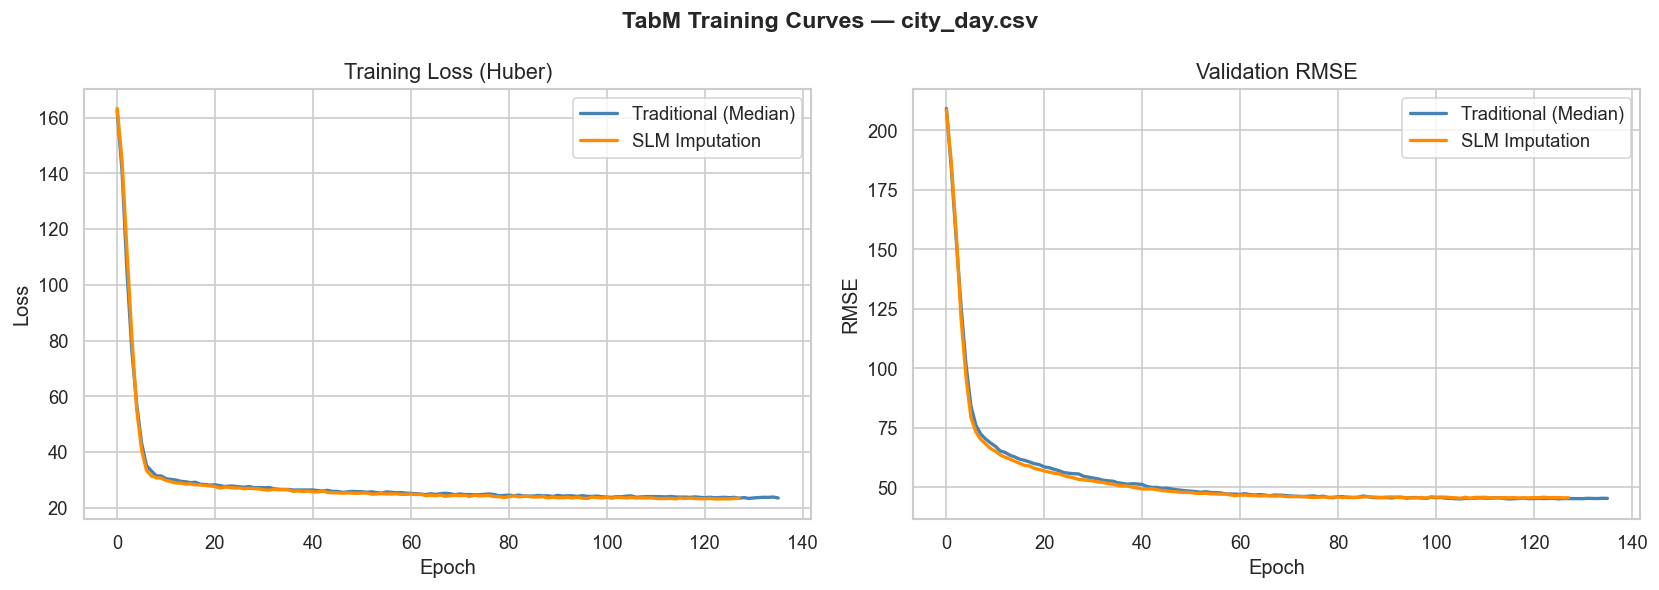

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_trad['train_loss'], label='Traditional (Median)',
             color='steelblue', lw=2)
axes[0].plot(history_slm['train_loss'],  label='SLM Imputation',
             color='darkorange', lw=2)
axes[0].set_title('Training Loss (Huber)', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_trad['val_rmse'], label='Traditional (Median)',
             color='steelblue', lw=2)
axes[1].plot(history_slm['val_rmse'],  label='SLM Imputation',
             color='darkorange', lw=2)
axes[1].set_title('Validation RMSE', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('TabM Training Curves — city_day.csv', fontsize=14, fontweight='bold')
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'cityday_tabm_training_curves.png')
plt.savefig(path, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()


## Step 13: Predicted vs Actual AQI Plots → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_pred_vs_actual.png


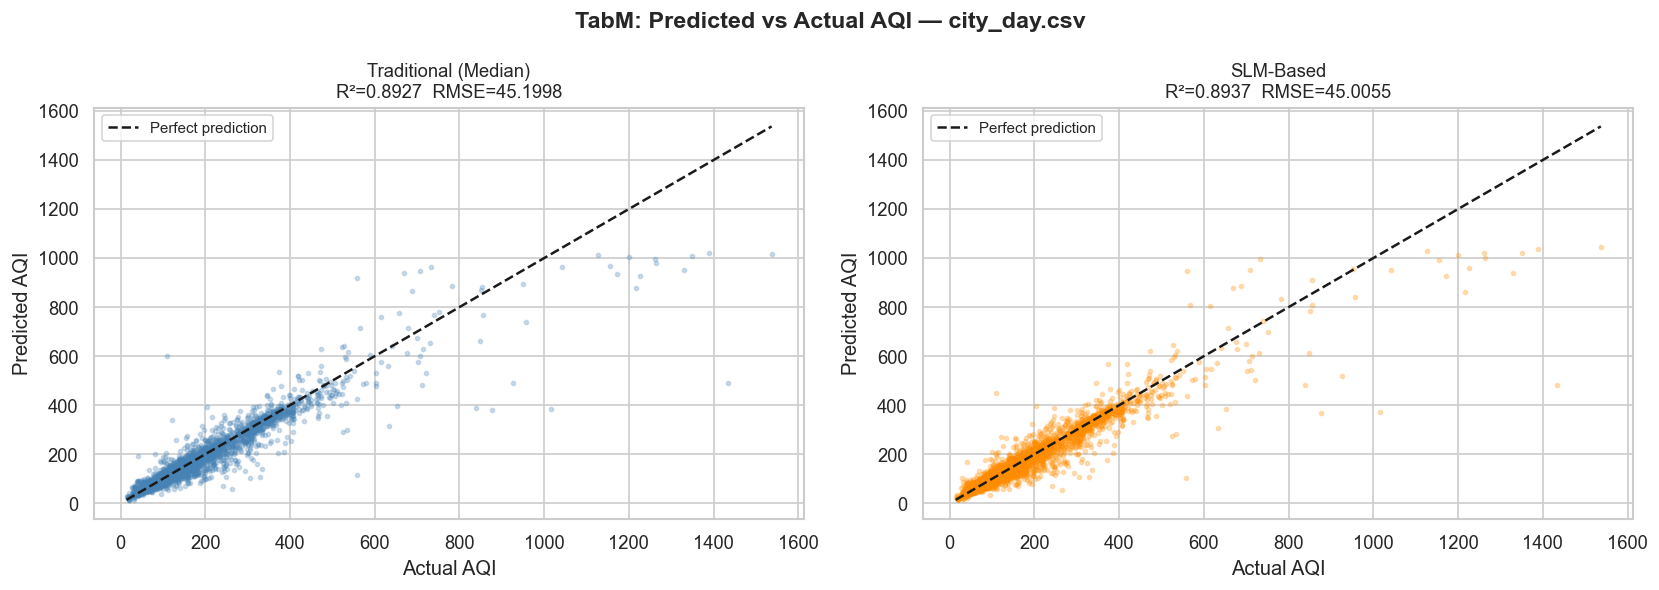

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Traditional (Median)', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM-Based',            'darkorange')
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=6, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{title}\nR²={r2:.4f}  RMSE={rmse:.4f}', fontsize=11)
    ax.set_xlabel('Actual AQI'); ax.set_ylabel('Predicted AQI')
    ax.legend(fontsize=9)

plt.suptitle('TabM: Predicted vs Actual AQI — city_day.csv',
             fontsize=14, fontweight='bold')
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'cityday_tabm_pred_vs_actual.png')
plt.savefig(path, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()


## Step 14: AQI Distribution — Actual vs Predicted → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_aqi_distribution.png


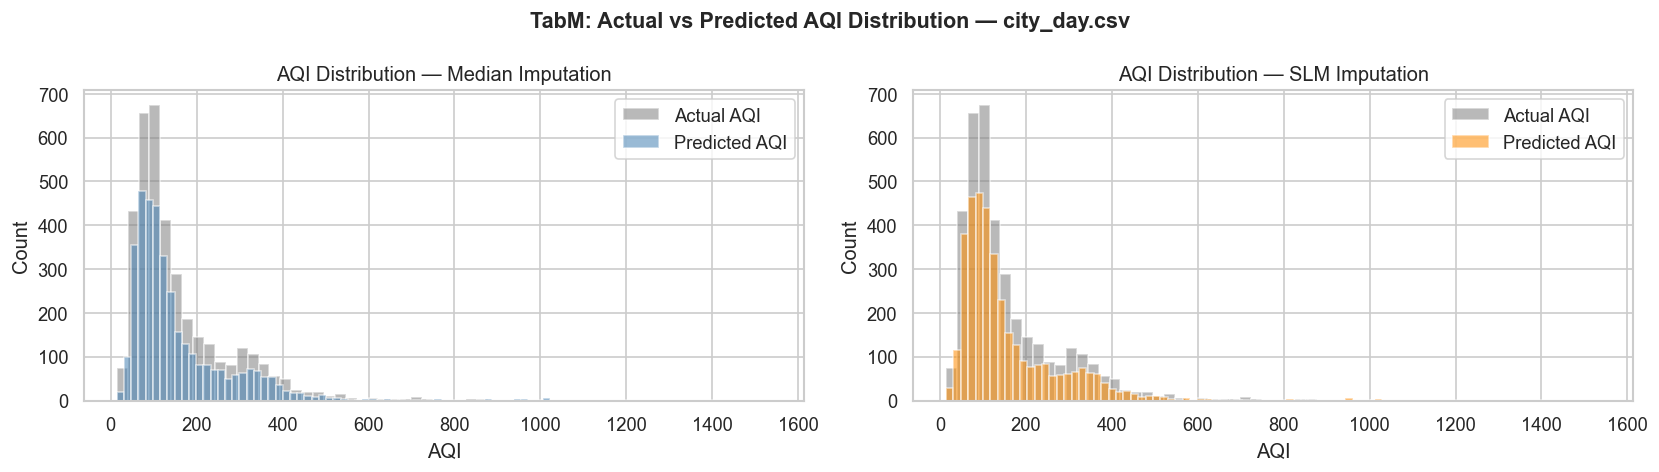

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_residuals.png


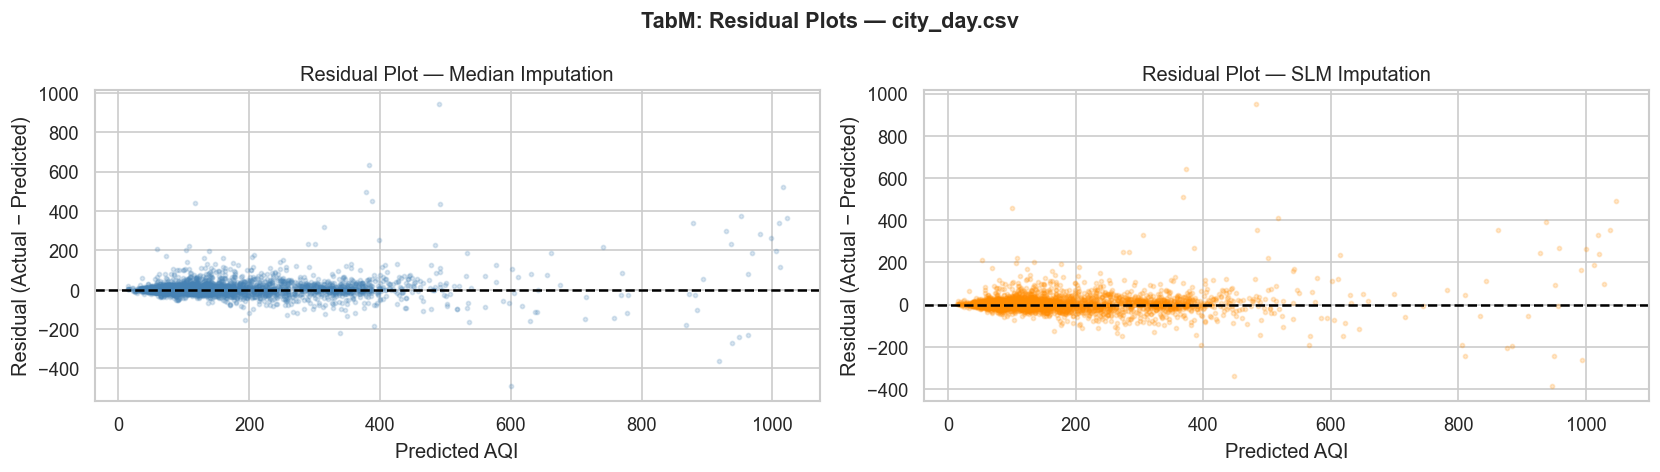

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Median Imputation', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM Imputation',    'darkorange')
]:
    ax.hist(y_true, bins=60, alpha=0.55, label='Actual AQI',    color='gray')
    ax.hist(y_pred, bins=60, alpha=0.55, label='Predicted AQI', color=color)
    ax.set_title(f'AQI Distribution — {title}', fontsize=12)
    ax.set_xlabel('AQI'); ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('TabM: Actual vs Predicted AQI Distribution — city_day.csv',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'cityday_tabm_aqi_distribution.png')
plt.savefig(path, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()

# ── Residual plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Median Imputation', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM Imputation',    'darkorange')
]:
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, s=6, color=color)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_title(f'Residual Plot — {title}', fontsize=12)
    ax.set_xlabel('Predicted AQI'); ax.set_ylabel('Residual (Actual − Predicted)')

plt.suptitle('TabM: Residual Plots — city_day.csv',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'cityday_tabm_residuals.png')
plt.savefig(path, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()


## Step 15: Final Results & Comparison → `results/`

In [19]:
results_df = pd.DataFrame(results)

print('\n' + '='*60)
print('       FINAL RESULTS — TabM on city_day.csv')
print('='*60)
print(results_df.to_string(index=False))

# ── Save CSV → results/ ───────────────────────────────────────────────────────
csv_path = os.path.join(RESULTS_DIR, 'cityday_tabm_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

# ── Improvement summary ───────────────────────────────────────────────────────
trad_row = results_df[results_df['Imputation'] == 'Median'].iloc[0]
slm_row  = results_df[results_df['Imputation'] == 'SLM'].iloc[0]

rmse_delta = trad_row['RMSE'] - slm_row['RMSE']
r2_delta   = slm_row['R2']   - trad_row['R2']
mae_delta  = trad_row['MAE'] - slm_row['MAE']

print('\n── Improvement (SLM over Median) ──')
print(f'  RMSE : {rmse_delta:+.4f}  ({"✅ better" if rmse_delta > 0 else "⚠ worse"})')
print(f'  MAE  : {mae_delta:+.4f}  ({"✅ better" if mae_delta  > 0 else "⚠ worse"})')
print(f'  R²   : {r2_delta:+.4f}  ({"✅ better" if r2_delta   > 0 else "⚠ worse"})')



       FINAL RESULTS — TabM on city_day.csv
Model Imputation    RMSE     MAE     R2
 TabM     Median 45.1998 20.9794 0.8927
 TabM        SLM 45.0055 21.3477 0.8937

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_results.csv

── Improvement (SLM over Median) ──
  RMSE : +0.1943  (✅ better)
  MAE  : -0.3683  (⚠ worse)
  R²   : +0.0010  (✅ better)


Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\cityday_tabm_comparison.png


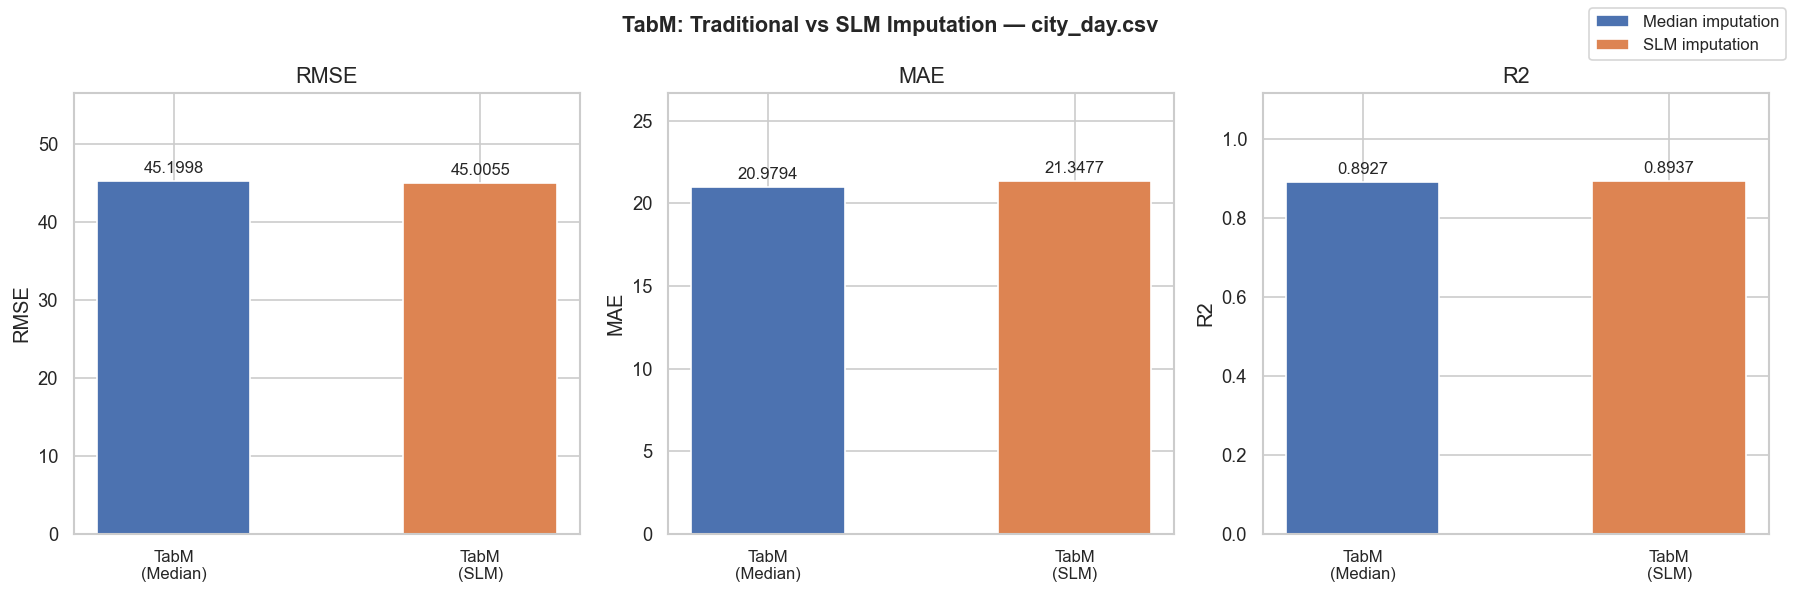

In [20]:
# ── Final comparison bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette   = {'Median': '#4C72B0', 'SLM': '#DD8452'}

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    colors_bar = [palette.get(i, 'gray') for i in results_df['Imputation']]
    labels     = results_df['Model'] + '\n(' + results_df['Imputation'] + ')'
    bars = ax.bar(labels, results_df[metric],
                  color=colors_bar, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(0, results_df[metric].max() * 1.25)
    ax.tick_params(axis='x', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Median imputation'),
                   Patch(facecolor='#DD8452', label='SLM imputation')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.suptitle('TabM: Traditional vs SLM Imputation — city_day.csv',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'cityday_tabm_comparison.png')
plt.savefig(path, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()


## Step 16: Final Folder Summary

In [21]:
print('\n' + '='*65)
print('           ALL FILES SAVED — FOLDER SUMMARY')
print('='*65)

folder_labels = [
    (DATA_RAW,       'data/raw/          — original CSV'),
    (DATA_PROCESSED, 'data/processed/    — imputed datasets'),
    (MODELS_DIR,     'models/            — trained .pt weights'),
    (RESULTS_DIR,    'results/           — plots + comparison CSV'),
    (LOGS_DIR,       'logs/              — training logs'),
]

for folder, label in folder_labels:
    files = os.listdir(folder)
    print(f'\n📁 {label}')
    if files:
        for f in sorted(files):
            size = os.path.getsize(os.path.join(folder, f))
            unit = 'KB' if size < 1_000_000 else 'MB'
            sz   = size/1024 if size < 1_000_000 else size/1_048_576
            print(f'   ✅  {f:<55} ({sz:.1f} {unit})')
    else:
        print('   (empty — run all cells above first)')



           ALL FILES SAVED — FOLDER SUMMARY

📁 data/raw/          — original CSV
   ✅  AP001.csv                                               (7.8 MB)
   ✅  README.md                                               (0.6 KB)
   ✅  city_day.csv                                            (2.5 MB)

📁 data/processed/    — imputed datasets
   ✅  AP001_cleaned.csv                                       (6.4 MB)
   ✅  AP001_median_imputed.csv                                (6.7 MB)
   ✅  README.md                                               (0.4 KB)
   ✅  city_day.csv                                            (0.1 KB)
   ✅  cityday_cleaned.csv                                     (5.4 MB)
   ✅  cityday_median_imputed.csv                              (4.7 MB)
   ✅  cityday_slm_imputed.csv                                 (7.4 MB)

📁 models/            — trained .pt weights
   ✅  AP001_ft_transformer_median.pt                          (623.6 KB)
   ✅  README.md                                   